# 루프 워크플로 구현하기 : 숫자 맞추기 게임

In [ ]:
# 랭그래프에서는 순환하는 그래프 구조도 만들 수 있습니다
# 조건이 만족할 때까지 루프를 실행하는 루프 워크플로를 손쉽게 작성할 수 있습니다
# 루프 패턴은 대화형 애플리케이션, 재시도 로직, 반복 작업 등에 활용할 수 있는 중요한 패턴


![](https://www.dropbox.com/scl/fi/2bxcu4uswk870nsxqk39f/0736482b-a0c3-4f2e-91f7-3029249aaccd.png?rlkey=21f25ckq7fydo5lggdschz42g&st=yir77tu8&dl=1)
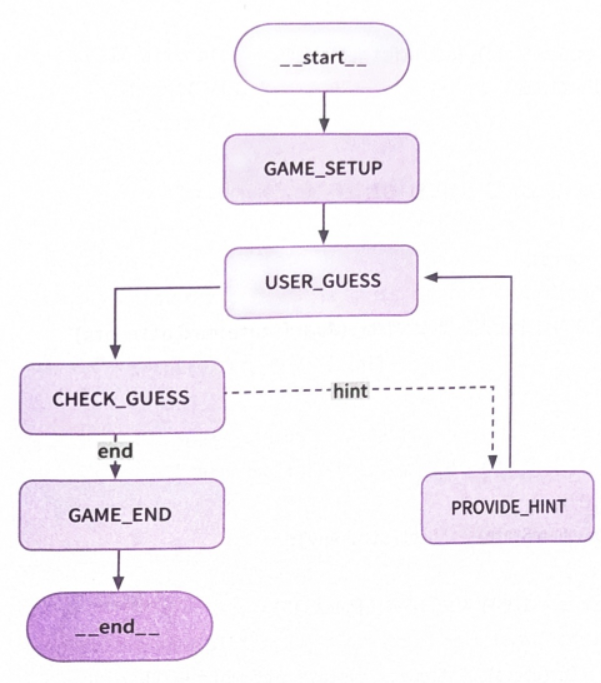

![](https://www.dropbox.com/scl/fi/dwd9svlzz8j1ps04ur185/ffb42ee3-2087-4410-8cdb-64c07f9768fa.png?rlkey=19x9806qrywqvt4mesw3vvh2d&st=j4rgehni&dl=1)
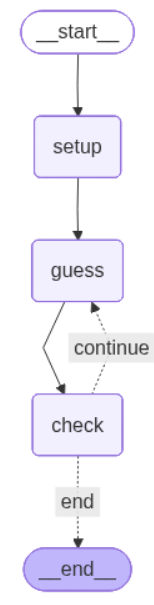

# import

In [4]:
from dotenv import load_dotenv
print(load_dotenv())

from typing import Dict, Any, Literal
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
import random
from IPython.display import Image, display

True


# 그래프 상태 정의

In [5]:
# ① 그래프 상태 정의 - LangGraph의 핵심 개념
class GuessGameState(BaseModel):
    target_number: int = Field(default=0, description="맞춰야 할 숫자")
    user_guess: int = Field(default=0, description="사용자 추측")
    attempts: int = Field(default=0, description="시도 횟수")
    max_attempts: int = Field(default=5, description="최대 시도 횟수")
    game_status: str = Field(default="playing", description="게임 상태")
    response: str = Field(default="", description="응답 메시지")


# 게임 설정 노드

In [6]:
# 상태 업데이트
# 변경하려는 필드를 딕셔너리로 반환하면 랭그래프가 자동으로 기존 상태와 병합하여 업데이트합니다. 
# ↓ '게임 설정 노드' 에서는 맞춰야 할 숫자와 게임 상태, 응답, 시도 횟수를 반환하여 업데이트합니다.

In [7]:
# 게임 설정 노드
def game_setup(state: GuessGameState) -> Dict[str, Any]:
    target = random.randint(1, 50)
    print('📌게임 시작!')
    
    return {
        "target_number": target,
        "game_status": "playing",
        "response": f"1~50 사이의 숫자를 맞춰보세요! (최대 {state.max_attempts}회)",
        "attempts": 0,
    }


# 게임 상태에 따른 분기 처리

In [8]:
#  게임 상태에 따른 분기 처리: game_status 필드를 통해 게임의 현재 상태를 추적합니다. 
# "playing", "won", "lost" 상태로 게임 진행을 제어합니다. 
# 이 상태는 라우팅 함수에서 다음 경로를 결정하는 데 사용됩니다

In [12]:
# 사용자 추측 노드 (시뮬레이션)
def user_guess(state: GuessGameState) -> Dict[str, Any]:
    guess = input("입력 :")
    print(f"[{state.attempts + 1}번째 시도] 추측: {guess}")

    return {"user_guess": int(guess), "attempts": state.attempts + 1}


# 추측 확인 노드
def check_guess(state: GuessGameState) -> Dict[str, Any]:
    target = state.target_number
    guess = state.user_guess
    attempts = state.attempts

    print(f"🟦[check_guess] {guess} (시도: {attempts}회)")

    # ③ 게임 상태에 따른 분기 처리
    if guess == target:    
        print('✅ 정답!')
        return {
            "game_status": "won",
            "response": f"정답! {guess}를 {attempts}번 만에 맞췄습니다!",
        }        
    elif attempts >= state.max_attempts:
        print("💥시도 횟수 초과!")
        return {
            "game_status": "lost",
            "response": f"게임 종료! 정답은 {target}이었습니다.",
        }
    else:
        # 힌트 주기
        hint = "더 큰 수" if guess < target else "더 작은 수"
        remaining = state.max_attempts - attempts
        print(f"😓계속 진행: {hint}")
        return {
            "game_status": "playing",
            "response": f"{guess}는 틀렸습니다. '{hint}'를 시도해보세요! (남은 기회: {remaining}회)",
        }        

# 조건부 라우팅 함수

In [13]:
# game_status 가 "playing" 이면 -> "continue"
#                       아니면  -> "end"

In [14]:
# ④ 조건부 라우팅 함수
def route_game(state: GuessGameState) -> Literal["continue",  "end"]:
    print(f"라우팅 체크: 상태={state.game_status}, 시도={state.attempts}")
    if state.game_status == "playing":
        return "continue"
    else:
        return "end"

# 루프 워크플로우 그래프

In [17]:
# 루프 워크플로우 그래프 생성
def create_guess_game_graph():
    # ⑤ State Graph 초기화 : 상태 스키마(GuessGameState)를 지정하여 그래프를 생성합니다. 
    #  이렇게 하면 모든 노드가 같은 상태 구조를 사용하도록 강제됩니다.
    workflow = StateGraph(GuessGameState)

    # ⑥ 노드 추가 : 각 처리 단계를 개별 노드로 정의합니다. 노드 이름과 실행할 함수를 매핑합니다.
    workflow.add_node("setup", game_setup)
    workflow.add_node("guess", user_guess)
    workflow.add_node("check", check_guess)

    # ⑦ 선형 에지 설정: 기본적인 실행 흐름을 정의합니다. 
    #   START → setup → guess → check 순서로 진행됩니다. 단방향 흐름으로 예측 가능한 실행 경로를 만듭니다.
    workflow.add_edge(START, "setup")
    workflow.add_edge("setup", "guess")
    workflow.add_edge("guess", "check")


    # ⑧ 조건부 엣지 - 동적 라우팅으로 루프 구현
    #  : add_conditional_edges() 함수로 동적 라우팅을 구현합니다. 
    #    check 노드 실행후 route_game() 함수가 호출되어 다음 경로를 결정합니다. 
    #    "continue" 시 "guess"로 돌아가면서 루프를 실행합니다. 이는 랭그래프에서 반복 구조를 구현하는 표준 패턴입니다.
    workflow.add_conditional_edges(
        "check",
        route_game,
        {
            "continue": "guess",  # 게임 계속 -> 다시 추측 (루프!)
            "end":  END,    # 종료,
        }
    )

    # ⑨ 그래프 컴파일 - 실행 가능한 앱으로 변환
    #   : 정의된 노드와 에지를 실행 가능한 애플리케이션으로 변환합니다. 
    #     컴파일 과정에서 그래프 구조를 검증하고 최적화합니다.
    return workflow.compile()
    

# 실행

=== 루프 워크플로우 예제 ===

📌게임 시작!


입력 : 25


[1번째 시도] 추측: 25
🟦[check_guess] 25 (시도: 1회)
😓계속 진행: 더 큰 수
라우팅 체크: 상태=playing, 시도=1


입력 : 40


[2번째 시도] 추측: 40
🟦[check_guess] 40 (시도: 2회)
😓계속 진행: 더 작은 수
라우팅 체크: 상태=playing, 시도=2


...

[3번째 시도] 추측: 32
🟦[check_guess] 32 (시도: 3회)
😓계속 진행: 더 큰 수
라우팅 체크: 상태=playing, 시도=3


입력 : 36


[4번째 시도] 추측: 36
🟦[check_guess] 36 (시도: 4회)
😓계속 진행: 더 작은 수
라우팅 체크: 상태=playing, 시도=4


입력 : 34


[5번째 시도] 추측: 34
🟦[check_guess] 34 (시도: 5회)
💥시도 횟수 초과!
라우팅 체크: 상태=lost, 시도=5

최종 결과: 게임 종료! 정답은 35이었습니다.
게임 상태: lost
총 시도: 5회


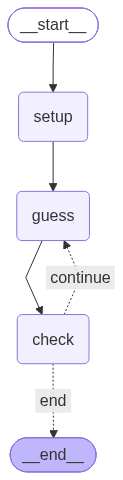

In [18]:
def main():
    print("=== 루프 워크플로우 예제 ===\n")

    app = create_guess_game_graph()

    # ⑩ 그래프 실행 - 초기 상태로 시작
    #  그래프 실행: invoke() 메서드로 초기 상태를 전달하여 워크플로를 시작합니다. 
    #  그래프는 정의된 경로를 따라 자동으로 실행되며, 조건부 에지에서 동적으로 경로를 선택합니다.
    initial_state = GuessGameState(max_attempts=5)
    result = app.invoke(initial_state)

    print(f"\n최종 결과: {result['response']}")
    print(f"게임 상태: {result['game_status']}")
    print(f"총 시도: {result['attempts']}회")    
    
    # 그래프 구조 출력
    display(Image(app.get_graph().draw_mermaid_png()))


if __name__ == "__main__":
    main()
